# Order Statistics-Based Jump Identification and Volatility Estimation

## Introduction

In financial time series, observed returns often contain a mixture of continuous fluctuations and sudden, discrete jumps. Standard volatility measures, such as sample standard deviation, do not distinguish between these two sources and therefore tend to overstate the true underlying (diffusive) volatility when jumps are present. The problem, then, is to separate “normal” market movements from extreme events in a principled and data-driven way.

The approach studied here addresses this problem by combining a jump-diffusion model with order statistics. The idea is to treat returns as if they were generated from a reference distribution under normal conditions, and then identify observations that are too extreme to be plausibly drawn from that distribution. These extreme observations are classified as jumps and removed, after which volatility is estimated from the remaining sample. The procedure is iterative, allowing both the classification and the volatility estimate to refine each other.

This notebook follows the implementation shared in:

--> https://github.com/sigmaquadro/VolatilityEstimator

and is based on the paper:

--> https://arxiv.org/abs/1803.07021

which develops an order statistics-based volatility estimator to separate the Brownian (continuous) component from jumps in financial time series. The authors are *Luca Spadafora*, *Francesca Sivero*, and *Nicola Picchiotti*.

---

## Methodology

The core idea is to identify jumps using rank-based probabilities derived from order statistics. Observations are first ordered and assumed to be i.i.d. from a posited distribution $F$ (typically Gaussian) under the null hypothesis of no jumps. For each of the $n$ observations, a probability is assigned based on its rank:

$$
P_o(k) = \sum_{i=k}^n \binom{n}{i} F(x)^i \bigg(1 - F(x)\bigg)^{n-i}.
$$

This quantity measures how extreme an observation is, given both its value and its position in the ordered sample. In other words, it accounts not only for magnitude, but also for how frequently such magnitudes should occur under $F$.

A classification rule is then imposed: if $P_o(k) < p^*$ for some chosen threshold $p^*$, the observation is deemed too unlikely under the reference distribution and is classified as a jump. Otherwise, it is retained as part of the continuous component.

This procedure is iterative. After each pass, observations classified as jumps are removed, and the probabilities $P_o(k)$ are recomputed on the reduced sample. The process repeats until the classification stabilizes. Stabilization occurs when the set of retained observations no longer changes from one iteration to the next, equivalently when all remaining observations satisfy $P_o(k) \ge p^*$ under the current configuration.

---

## Theoretical Framework

The method is motivated by modeling returns as a jump-diffusion process:

$$
dY_t = \sigma_t dW_t + dJ_t,
$$

where $\sigma_t dW_t$ represents continuous Gaussian variation and $dJ_t$ represents discrete jumps. The observed data therefore combine these two components, but only the continuous part should contribute to the estimation of volatility.

To isolate this component, we assume that in the absence of jumps, observations $\{X_i\}_{i=1}^n$ are i.i.d. from a distribution $F$. The order-statistics-based probability

$$
P_o(k) = \sum_{i=k}^n \binom{n}{i} F(x)^i (1 - F(x))^{n-i}
$$

arises from binomial counting and quantifies how likely it is to observe at least $k$ values below a given threshold under $F$. This provides a rank-dependent measure of extremeness.

Observations that violate the threshold condition $P_o(k) \ge p^*$ are attributed to the jump component $dJ_t$ and removed. The remaining observations are treated as realizations of the continuous component $\sigma_t dW_t$, and are used to estimate volatility.

Iterating this procedure yields a classification in which extreme-value considerations identify jumps, while the filtered sample provides an estimate of the underlying continuous volatility.

## Demonstration Setup

To illustrate the method in practice, we apply the order statistics volatility estimator to Tesla, using the adjusted close price series over the last five years. The adjusted close is downloaded with `auto_adjust=False`, and daily log returns are computed as
$$
r_t = \log\left(\frac{P_t}{P_{t-1}}\right).
$$
These returns form the input sample on which jump identification and volatility estimation are carried out.

The code follows the structure of the reference implementation, while also storing intermediate quantities for inspection. The main parameters are the ticker symbol `TSLA`, the probability threshold $p^* = 0.05$, the rolling bandwidth `60` used to estimate local volatility, and a maximum of `100` iterations. The bandwidth plays the role of a rolling window length: at each time step, volatility is estimated from the most recent `60` returns, excluding those currently classified as jumps.

The function `_kSmallestCDF` computes the rank-based probability using the regularized incomplete beta function. This is the key order-statistics object in the algorithm. The function `_thrLocalVol` computes the local volatility series after removing observations currently flagged as jumps. The function `_getkJumpProb_with_pvals` then orders the renormalized returns, evaluates their probabilities from both tails, and updates the Boolean jump indicator array according to whether each probability falls below the chosen threshold $p^*$.

The main routine `local_vol_order_stats_with_history` ties these pieces together. It begins by assuming that no return is a jump. It then alternates between estimating local volatility, renormalizing returns by that volatility, and reclassifying observations as jumps or non-jumps. The routine also stores the history of volatility estimates, jump classifications, probability vectors, and renormalized returns at each iteration. This is useful not only for the final result, but also for diagnosing how the classification evolves and whether it stabilizes.

In short, the demonstration is designed to do three things. First, it identifies which return observations are classified as jumps. Second, it estimates the continuous volatility after filtering those jumps out. Third, it records the intermediate evolution of the algorithm so that the convergence of the procedure can later be visualized and analyzed.

This implementation follows the version provided in the reference GitHub repository, with a bandwidth of 60 chosen to correspond roughly to a quarter of a trading year, and a threshold $p^* = 0.05$ adopted as a widely used default.

In [17]:
import copy
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.special import betainc
from matplotlib.animation import FuncAnimation

# =========================
# Data
# =========================
ticker = "TSLA"
p_star = 0.05
bandwidth = 60
max_iter = 100
period = "5y"

df = yf.download(ticker, period=period, auto_adjust=False, progress=False)
px = df["Adj Close"].dropna().copy()
ret = np.log(px / px.shift(1)).dropna().astype(float)

# =========================
# Repo-style core functions
# =========================
def _kSmallestCDF(x, k, n):
    return betainc(float(k), n - float(k) + 1.0, norm.cdf(x, 0.0, 1.0))

def _thrLocalVol(ret_arr, bandwidth, ju):
    no_ju = 1.0 - ju.astype(float)
    vol = np.zeros(ret_arr.shape[0], dtype=float)

    for i in np.arange(bandwidth - 1, ret_arr.shape[0]):
        r_win = ret_arr[i + 1 - bandwidth:i + 1] * no_ju[i + 1 - bandwidth:i + 1]
        n_keep = np.sum(no_ju[i + 1 - bandwidth:i + 1])
        if n_keep <= 0:
            vol[i] = np.nan
        else:
            vol[i] = np.sqrt(np.sum(r_win ** 2.0) / n_keep)

    if np.isnan(vol[bandwidth - 1]):
        vol[bandwidth - 1] = np.nanstd(ret_arr[:bandwidth])

    vol[:bandwidth] = vol[bandwidth - 1]
    vol = pd.Series(vol).ffill().bfill().to_numpy()
    vol = np.maximum(vol, 1e-12)
    return vol

def _getkJumpProb_with_pvals(ret_ren, ju, prob_cut_off):
    ret_ren_indx = np.argsort(ret_ren)
    ret_sort = np.sort(ret_ren).astype(np.double)

    n = ret_ren.shape[0]
    n_1 = n
    k_gauss1 = 1
    k_gauss2 = 1

    pvals = np.full(n, np.nan, dtype=float)

    for k in np.arange(1, int(n * 0.5) + 1):
        # left tail
        i_left = ret_ren_indx[k - 1]
        if ju[i_left]:
            n_1 -= 1
        else:
            prob = _kSmallestCDF(ret_sort[k - 1], k_gauss1, n_1)
            pvals[i_left] = prob
            if prob <= prob_cut_off:
                ju[i_left] = True
                n_1 -= 1
            else:
                k_gauss1 += 1

        # right tail
        i_right = ret_ren_indx[n - k]
        if ju[i_right]:
            n_1 -= 1
        else:
            prob = _kSmallestCDF(-ret_sort[n - k], k_gauss2, n_1)
            pvals[i_right] = prob
            if prob <= prob_cut_off:
                ju[i_right] = True
                n_1 -= 1
            else:
                k_gauss2 += 1

    if n % 2 == 1:
        mid = ret_ren_indx[n // 2]
        pvals[mid] = np.nan

    return ju, pvals

def local_vol_order_stats_with_history(ret_arr, bandwidth, prob_cut_off=0.05, max_iter=100):
    ju = np.zeros(ret_arr.shape[0], dtype=bool)

    vol_hist = []
    ju_hist = []
    pval_hist = []
    ret_ren_hist = []

    for _ in range(max_iter):
        ju_old = copy.deepcopy(ju)

        vol = _thrLocalVol(ret_arr, bandwidth, ju)
        ret_ren = (ret_arr / vol).astype(np.double)

        ju, pvals = _getkJumpProb_with_pvals(ret_ren, ju, prob_cut_off)

        # same repo rule: neglect jumps lower than volatility estimate
        ju[np.abs(ret_arr) < vol] = False

        vol_hist.append(vol.copy())
        ju_hist.append(ju.copy())
        pval_hist.append(pvals.copy())
        ret_ren_hist.append(ret_ren.copy())

        if np.array_equal(ju_old, ju):
            break

    vol = _thrLocalVol(ret_arr, bandwidth, ju)
    return vol, ju, vol_hist, ju_hist, pval_hist, ret_ren_hist

In [18]:
# =========================
# Run
# =========================
ret_arr = ret.values.flatten()
vol_os, ju, vol_hist, ju_hist, pval_hist, ret_ren_hist = local_vol_order_stats_with_history(
    ret_arr, bandwidth=bandwidth, prob_cut_off=p_star, max_iter=max_iter
)

# Annualized continuous vol series
ann_vol = vol_os * np.sqrt(252)

# Jump dates for returns
jump_ret_dates = ret.index[ju]

# Map return jumps to price dates (jump in return at t belongs to price at t)
jump_px_dates = jump_ret_dates.intersection(px.index)
jump_px_vals = px.loc[jump_px_dates]

print(f"Iterations: {len(pval_hist)}")
print(f"Detected jumps: {ju.sum()} out of {len(ju)} returns")
print(f"Latest continuous annualized vol: {ann_vol[-1]:.4f}")

Iterations: 4
Detected jumps: 15 out of 1255 returns
Latest continuous annualized vol: 0.3711


This implementation follows the version provided in the reference GitHub repository, with a bandwidth of 60 chosen to correspond roughly to a quarter of a trading year, and a threshold $p^* = 0.05$ adopted as a widely used default.

Just to recap, each iteration proceeds as follows: given the current classification of jumps, we first estimate the local volatility using only the observations not flagged as jumps; we then renormalize returns by this volatility and compute the rank-based probabilities $P_o(k)$; finally, observations with $P_o(k) < p^*$ are classified as jumps and removed. This process is repeated until the classification stabilizes. In this case, the fourth iteration is the last because no new observations are identified as jumps, i.e. all remaining observations satisfy $P_o(k) \geq p^*$ under the current configuration.

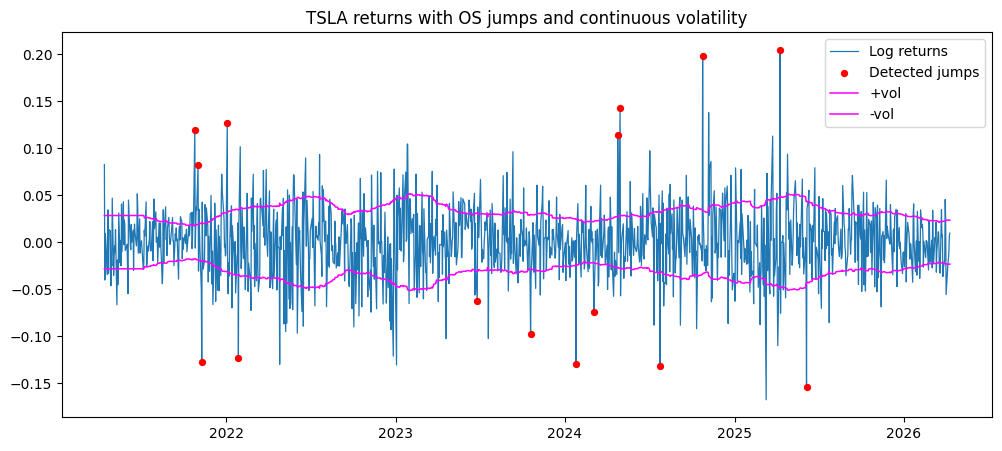

In [19]:
# =========================
# Plot 1: returns + jumps + volatility bands
# =========================
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ret.index, ret_arr, lw=0.9, label="Log returns")
ax.scatter(ret.index[ju], ret_arr[ju], color="red", s=18, label="Detected jumps", zorder=3)
ax.plot(ret.index, vol_os, color="magenta", lw=1.1, label="+vol")
ax.plot(ret.index, -vol_os, color="magenta", lw=1.1, label="-vol")
ax.set_title(f"{ticker} returns with OS jumps and continuous volatility")
ax.legend()
plt.show()

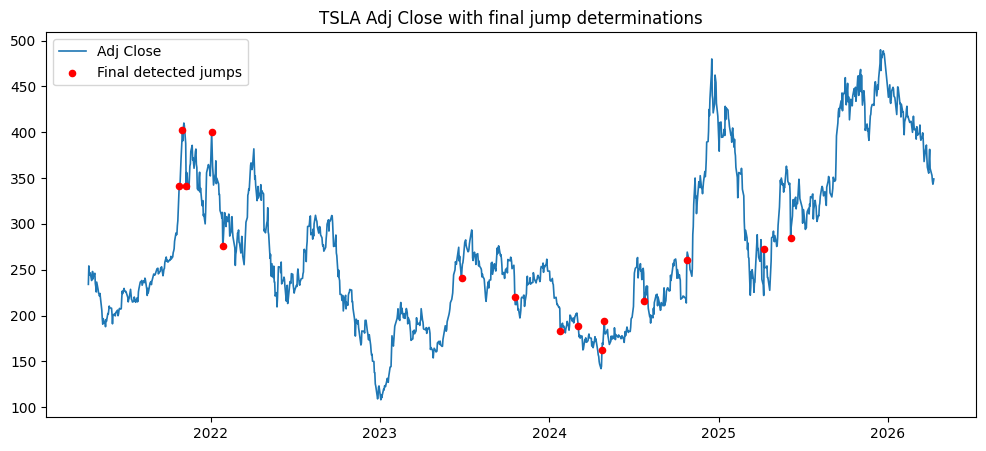

In [40]:
# =========================
# Plot 2: Adj Close + final jump markers
# =========================
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(px.index, px.values, lw=1.2, label="Adj Close")
ax.scatter(jump_px_dates, jump_px_vals, color="red", s=20, label="Final detected jumps", zorder=3)
ax.set_title(f"{ticker} Adj Close with final jump determinations")
ax.legend()
plt.show()

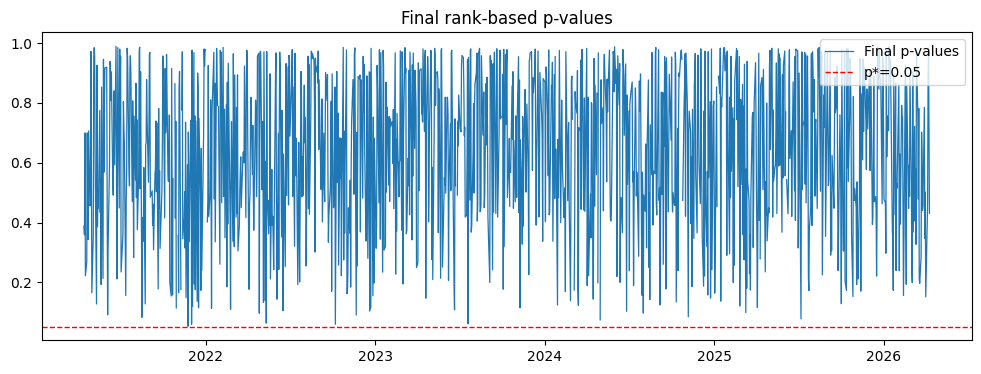

In [39]:
# =========================
# Plot 3: final p-values vs threshold
# =========================
final_p = pval_hist[-1]
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ret.index, final_p, lw=0.9, label="Final p-values")
ax.axhline(p_star, color="red", ls="--", lw=1.0, label=f"p*={p_star}")
ax.set_title("Final rank-based p-values")
ax.legend(loc="upper right")
plt.show()

In [44]:
# =========================
# Optional animation: p-values stabilizing
# =========================
def animate_pvals(pval_hist, dates, p_star=0.05, interval=120):
    fig, ax = plt.subplots(figsize=(10, 4))
    line, = ax.plot([], [], lw=0.9)
    thr = ax.axhline(p_star, color="red", ls="--", lw=1.0)
    txt = ax.text(0.01, 0.95, "", transform=ax.transAxes, va="top")

    ymin = np.nanmin([np.nanmin(v) for v in pval_hist if np.isfinite(v).any()])
    ymax = np.nanmax([np.nanmax(v) for v in pval_hist if np.isfinite(v).any()])
    ax.set_xlim(dates.min(), dates.max())
    ax.set_ylim(max(0.0, ymin - 0.02), min(1.0, ymax + 0.02))
    ax.set_title("Iteration-by-iteration p-values")
    ax.set_xlabel("Date")

    def init():
        line.set_data([], [])
        txt.set_text("")
        return line, thr, txt

    def update(frame):
        y = pval_hist[frame]
        line.set_data(dates, y)
        txt.set_text(f"iteration = {frame + 1}")
        return line, thr, txt

    anim = FuncAnimation(fig, update, frames=len(pval_hist), init_func=init,
                         interval=interval, blit=True)
    plt.close(fig)
    return anim

anim = animate_pvals(pval_hist, ret.index, p_star=p_star)

# In Jupyter:
from IPython.display import HTML
HTML(anim.to_jshtml())

# Or save:
# anim.save("tsla_pvals.gif", writer="pillow", fps=5)

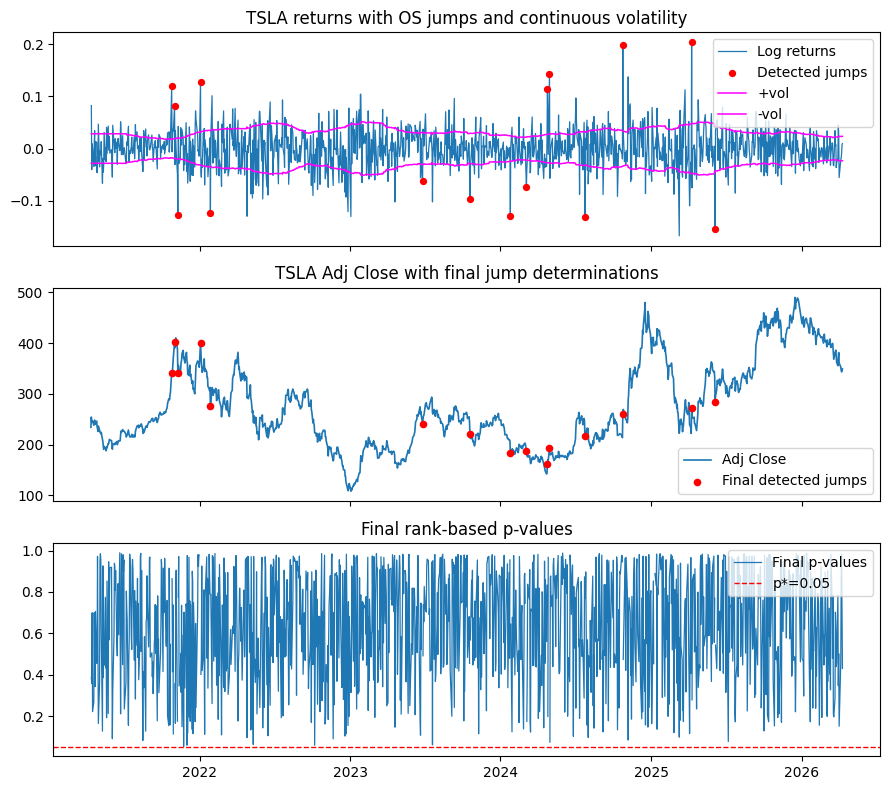

In [33]:
# =========================
# Combined 3-panel plot (for convenience in saving plots)
# =========================
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)

# --- Panel 1: returns + jumps + volatility bands ---
axes[0].plot(ret.index, ret_arr, lw=0.9, label="Log returns")
axes[0].scatter(ret.index[ju], ret_arr[ju], color="red", s=18, label="Detected jumps", zorder=3)
axes[0].plot(ret.index, vol_os, color="magenta", lw=1.1, label="+vol")
axes[0].plot(ret.index, -vol_os, color="magenta", lw=1.1, label="-vol")
axes[0].set_title(f"{ticker} returns with OS jumps and continuous volatility")
axes[0].legend(loc="upper right")

# --- Panel 2: Adj Close + jump markers ---
axes[1].plot(px.index, px.values, lw=1.2, label="Adj Close")
axes[1].scatter(jump_px_dates, jump_px_vals, color="red", s=20, label="Final detected jumps", zorder=3)
axes[1].set_title(f"{ticker} Adj Close with final jump determinations")
axes[1].legend(loc="lower right")

# --- Panel 3: final p-values vs threshold ---
final_p = pval_hist[-1]
axes[2].plot(ret.index, final_p, lw=0.9, label="Final p-values")
axes[2].axhline(p_star, color="red", ls="--", lw=1.0, label=f"p*={p_star}")
axes[2].set_title("Final rank-based p-values")
axes[2].legend(loc="upper right")

plt.tight_layout()
plt.savefig("tsla_combined.png", dpi=300, bbox_inches="tight")
plt.show()

## Modification: Sensitivity Analysis with Respect to $p^*$

After running the estimator with the conventional choice $p^* = 0.05$, it is natural to ask how sensitive the final classification is to this threshold. Since $p^*$ directly controls how aggressively observations are labeled as jumps, changing it may alter the number of detected jumps, the number of iterations required for convergence, and the resulting continuous volatility estimate. For this reason, we do not stop at a single default value, but instead examine the behavior of the algorithm over a grid of candidate thresholds.

The code above performs exactly this sensitivity analysis. A grid of values for $p^*$ is constructed, ranging from $0.005$ to $0.150$ in increments of $0.005$. For each value in this grid, the full order-statistics volatility estimator is rerun on the same return series. The resulting outputs are then summarized in terms of three key quantities: the number of iterations needed for the algorithm to stabilize, the number of observations ultimately classified as jumps, and the latest continuous annualized volatility estimate.

The rationale is straightforward. If the method is robust, then there should exist a range of $p^*$ values over which these outputs remain broadly stable. In particular, if increasing $p^*$ further produces little or no material change in the jump count, the iteration count, or the volatility estimate, then one may regard the procedure as having entered a stable region. On the other hand, if these quantities begin to change abruptly as $p^*$ increases, that suggests the method is becoming overly aggressive in classifying observations as jumps.

To support later inspection and visualization, the code stores results at two levels. First, a compact summary table `grid_df` is created, with one row per choice of $p^*$. Second, a dictionary `grid_results` retains the full outputs of each run, including the volatility paths, jump histories, probability histories, and dates of identified jumps. This allows both a high-level comparison across thresholds and a more detailed examination of any particular case.

In short, this modification turns the single-threshold implementation into a threshold-selection experiment. Rather than accepting a default value mechanically, we study how the algorithm behaves as $p^*$ varies, with the aim of identifying a range beyond which further increases in the threshold become immaterial or destabilizing.

In [34]:
import numpy as np
import pandas as pd

# ==========================================
# Grid over p* with step 0.005
# Assumes these already exist in memory:
# ret, ret_arr, local_vol_order_stats_with_history
# ==========================================

# p* grid
p_grid = np.round(np.arange(0.005, 0.150 + 0.005, 0.005), 3)

# containers
grid_rows = []
grid_results = {}

for p_star_i in p_grid:
    vol_os_i, ju_i, vol_hist_i, ju_hist_i, pval_hist_i, ret_ren_hist_i = \
        local_vol_order_stats_with_history(
            ret_arr,
            bandwidth=bandwidth,
            prob_cut_off=float(p_star_i),
            max_iter=max_iter
        )

    ann_vol_i = vol_os_i * np.sqrt(252)
    latest_ann_vol_i = float(ann_vol_i[-1])
    n_iter_i = len(pval_hist_i)
    n_jumps_i = int(np.sum(ju_i))

    # summary row for table / later plotting
    grid_rows.append({
        "p_star": float(p_star_i),
        "iterations": n_iter_i,
        "n_jumps": n_jumps_i,
        "latest_ann_vol": latest_ann_vol_i
    })

    # full objects for later plotting / inspection
    grid_results[float(p_star_i)] = {
        "p_star": float(p_star_i),
        "vol_os": vol_os_i,
        "ann_vol": ann_vol_i,
        "ju": ju_i,
        "vol_hist": vol_hist_i,
        "ju_hist": ju_hist_i,
        "pval_hist": pval_hist_i,
        "ret_ren_hist": ret_ren_hist_i,
        "jump_ret_dates": ret.index[ju_i],
        "jump_ret_vals": ret.iloc[ju_i],
        "n_iter": n_iter_i,
        "n_jumps": n_jumps_i,
        "latest_ann_vol": latest_ann_vol_i
    }

# summary DataFrame
grid_df = pd.DataFrame(grid_rows)

# convenient arrays for plotting later
p_star_vec = grid_df["p_star"].to_numpy()
iter_vec   = grid_df["iterations"].to_numpy()
jump_vec   = grid_df["n_jumps"].to_numpy()
vol_vec    = grid_df["latest_ann_vol"].to_numpy()

# view the summary table
print(grid_df)

    p_star  iterations  n_jumps  latest_ann_vol
0    0.005           4        9        0.371126
1    0.010           4       11        0.371126
2    0.015           5       12        0.371126
3    0.020           4       12        0.371126
4    0.025           5       14        0.371126
5    0.030           5       14        0.371126
6    0.035           5       15        0.371126
7    0.040           5       16        0.371126
8    0.045           4       15        0.371126
9    0.050           4       15        0.371126
10   0.055           4       16        0.371126
11   0.060           5       17        0.371126
12   0.065           5       17        0.371126
13   0.070           5       17        0.371126
14   0.075           5       18        0.371126
15   0.080           5       21        0.371126
16   0.085          10       35        0.371126
17   0.090           8       31        0.371126
18   0.095          27       72        0.371126
19   0.100          10       42        0

### Analysis of Results

The sensitivity analysis over $p^*$ reveals a clear structure in the behavior of the algorithm. For values of $p^*$ up to approximately $0.075$–$0.080$, the outputs are remarkably stable. In this region, the number of iterations required for convergence remains low (around 4–5), the number of detected jumps increases gradually and smoothly, and the latest continuous annualized volatility remains essentially unchanged at approximately $0.3711$. This indicates that, within this range, the classification is robust and the estimator is not overly sensitive to the exact choice of $p^*$.

Beyond this range, however, the behavior changes noticeably. Starting around $p^* \approx 0.085$, the number of iterations begins to increase sharply, and the number of detected jumps exhibits large and erratic jumps. This suggests that the algorithm is becoming overly aggressive in classifying observations as jumps, leading to instability in the iterative procedure. Correspondingly, the volatility estimate begins to fluctuate, indicating that the underlying classification is no longer stable.

This transition can be interpreted as a form of threshold-induced instability: below a certain level, increasing $p^*$ has little effect on the outcome, but beyond that point, the classification changes materially and unpredictably. From a practical standpoint, one would therefore select a value of $p^*$ within the stable region, and ideally as close as possible to the boundary before instability sets in.

In this context, the choice $p^* = 0.08$ is well justified. It lies at the upper edge of the stable regime, capturing a larger set of jumps than more conservative choices (such as $0.05$), while still avoiding the onset of instability. In other words, it represents a data-driven balance: sufficiently aggressive to identify meaningful extreme events, but not so aggressive as to distort the volatility estimate or destabilize the algorithm.

The following plots give a visual illustration of the results.

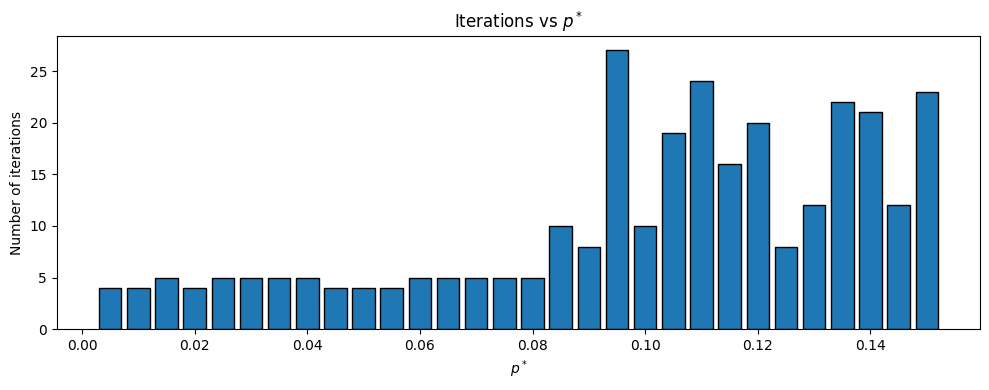

In [41]:
# =========================
# Bar chart: iterations vs p*
# =========================
fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(p_star_vec, iter_vec, width=0.004, edgecolor='black')

ax.set_xlabel(r"$p^*$")
ax.set_ylabel("Number of iterations")
ax.set_title("Iterations vs $p^*$")

plt.tight_layout()
plt.show()

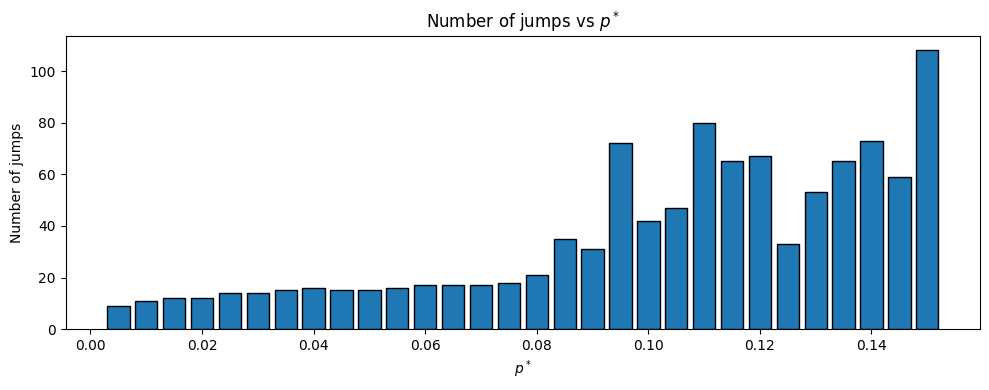

In [42]:
# =========================
# Bar chart: number of jumps vs p*
# =========================
fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(p_star_vec, jump_vec, width=0.004, edgecolor='black')

ax.set_xlabel(r"$p^*$")
ax.set_ylabel("Number of jumps")
ax.set_title("Number of jumps vs $p^*$")

plt.tight_layout()
plt.show()

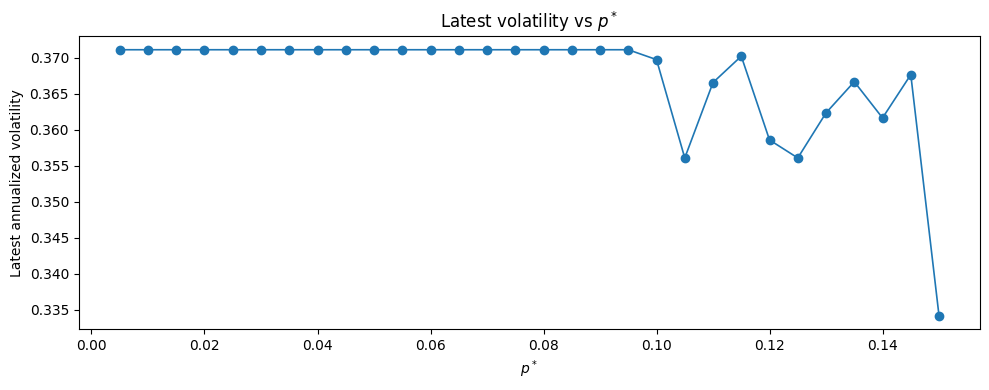

In [43]:
# =========================
# Line plot: latest vol vs p*
# =========================
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(p_star_vec, vol_vec, marker='o', lw=1.2)

ax.set_xlabel(r"$p^*$")
ax.set_ylabel("Latest annualized volatility")
ax.set_title("Latest volatility vs $p^*$")

plt.tight_layout()
plt.show()

Based on the results tabulated above, a choice of $p^* = 0.08$ should not differ materially from the baseline choice of $p^* = 0.05$ examined above. Both lie within the stable region, yielding the same continuous volatility estimate (approximately $0.3711$) and similar convergence behavior (around 4–5 iterations). The main difference is that $p^* = 0.08$ identifies slightly more jumps (21 versus 15), reflecting a more aggressive but still controlled classification. Overall, the two choices lead to essentially the same volatility conclusion, with $0.08$ providing a modest extension in jump detection without altering the core result.